In [98]:
import pandas as pd

In [99]:
df = pd.read_parquet("hf://datasets/sharjeelyunus/github-issues-dataset/github_issues_dataset.parquet")

In [100]:
df.drop(["id"], axis=1, inplace=True)

In [101]:
df.sample(5)

,repo,title,body,labels,priority,severity
69500,storybook,[Bug]: Storybook minifies dist output,### Describe the bug\r\n\r\nIt's quite hard to...,feature request,low,Critical
4583,vscode,[theming] Allow theming workbench fonts,Including\r\n\r\n- Family\r\n- Weight\r\n- Sty...,"feature-request,themes",high,Critical
80772,pytorch,`test_autograd_dense_output_addmm` fails if ma...,"### 🐛 Describe the bug\n\nFor example, if one ...","module: sparse,triaged",low,Critical
65376,storybook,[Feature Request]: Automatically type arg mapp...,### Is your feature request related to a probl...,"feature request,typescript,argtypes",low,Minor
86144,rust,ICE: `Assignment between coroutine saved local...,<!--\r\n[31mICE[0m: Rustc ./ice.rs '-Zvalida...,"I-ICE,T-compiler,C-bug,F-coroutines,-Zvalidate...",low,Critical


In [102]:
df["repo"].value_counts()

repo
pytorch                  14451
flutter                  13130
godot                    11207
rust                      9925
go                        9094
                         ...  
d3                           3
clean-code-javascript        2
fucking-algorithm            2
awesome                      1
awesome-go                   1
Name: count, Length: 68, dtype: int64

In [103]:
df = df.apply(lambda col: col.str.lower())

In [104]:
# df["repo"].fillna(" ") + " " + 
# df["labels"].fillna(" ") + " " + 

# df["title"].fillna(" ") + " " + 

df["text"] = df["title"].fillna(" ") + " " + df["body"].fillna(" ")
df.drop(['repo', 'title', 'body', 'labels', 'priority'], inplace=True, axis=1) 

In [105]:
df['severity'].value_counts(normalize=True)*100

severity
critical    58.288114
minor       26.096447
major       15.615439
Name: proportion, dtype: float64

In [106]:
# from sklearn.feature_extraction.text import CountVectorizer

# vectorizer = CountVectorizer(stop_words='english', min_df=0.01, max_df=0.90, ngram_range=(1,2))

# text_vec = vectorizer.fit_transform(df['text'])

# vectorizer.get_feature_names_out()

In [107]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', min_df=0.01, max_df=0.9, ngram_range=(1,5))

text_vec = tfidf.fit_transform(df['text'])

In [108]:
len(tfidf.get_feature_names_out())

4511

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(text_vec, df["severity"], test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=100, class_weight='balanced')

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print(accuracy_score(y_test, y_pred))

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=logreg.classes_))

c:\Users\arsal\Desktop\support-ticket-triage-system\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7772956388341004
              precision    recall  f1-score   support

    critical       0.99      0.87      0.93     13306
       major       0.43      0.59      0.50      3595
       minor       0.65      0.68      0.66      5914

    accuracy                           0.78     22815
   macro avg       0.69      0.71      0.70     22815
weighted avg       0.81      0.78      0.79     22815



0.8048213894367741
              precision    recall  f1-score   support

    critical       0.94      0.93      0.93     13306
       major       0.56      0.30      0.39      3595
       minor       0.64      0.84      0.73      5914

    accuracy                           0.80     22815
   macro avg       0.71      0.69      0.68     22815
weighted avg       0.80      0.80      0.79     22815

In [110]:
X_train.shape

(91258, 4511)

In [111]:
print(set(y_train))

{'critical', 'minor', 'major'}


In [112]:
from sklearn.svm import LinearSVC

lsvc = LinearSVC(max_iter=100, dual=False, class_weight='balanced')
lsvc.fit(X_train, y_train)
y_pred_lsvc = lsvc.predict(X_test)
print(accuracy_score(y_test, y_pred_lsvc))

0.8144641683103222


In [113]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lsvc, target_names=logreg.classes_))


              precision    recall  f1-score   support

    critical       0.99      0.92      0.95     13306
       major       0.50      0.49      0.49      3595
       minor       0.66      0.78      0.71      5914

    accuracy                           0.81     22815
   macro avg       0.72      0.73      0.72     22815
weighted avg       0.83      0.81      0.82     22815



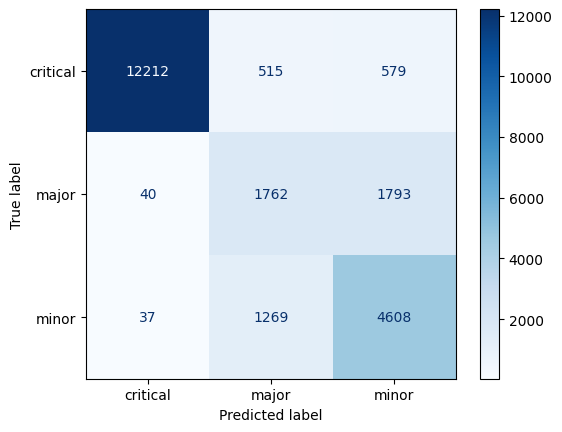

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['critical', 'major', 'minor']

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lsvc,
    labels=labels,
    display_labels=labels,
    cmap='Blues'
 )

plt.show()

0.8170501862809555---------------------------------0.7899627438088976

at min_df=0.2, max_df=0.9

0.7248301555993863--------------------------------0.719307473153627

at min_df=0.1, max_df=0.9

0.7557747096208635-------------------------------0.7493315801008109

at min_df=0.01, max_df=0.9

0.8319088319088319

              precision    recall  f1-score   support

    critical       0.95      0.94      0.95     13306
       major       0.59      0.38      0.46      3595
       minor       0.69      0.86      0.76      5914


    accuracy                           0.83     22815
    macro avg       0.74      0.73      0.73     22815
    weighted avg       0.83      0.83      0.82     22815

### After removing repo column from text

0.8310760464606618

              precision    recall  f1-score   support

    critical       0.96      0.94      0.95     13306
       major       0.59      0.39      0.47      3595
       minor       0.69      0.85      0.76      5914

    accuracy                           0.83     22815
    macro avg       0.74      0.73      0.73     22815
    weighted avg       0.83      0.83      0.82     22815



### After removing labels / title + body + priority

0.843962305500767

              precision    recall  f1-score   support

    critical       0.98      0.95      0.96     13306
       major       0.61      0.36      0.45      3595
       minor       0.69      0.90      0.78      5914

    accuracy                           0.84     22815
      macro avg       0.76      0.74      0.73     22815
      weighted avg       0.84      0.84      0.83     22815



### After removing priority / title + body

0.8223975454744685

              precision    recall  f1-score   support

    critical       0.98      0.93      0.96     13306
       major       0.58      0.32      0.41      3595
       minor       0.64      0.88      0.74      5914

    accuracy                           0.82     22815
    macro avg       0.73      0.71      0.70     22815
    weighted avg       0.83      0.82      0.81     22815


### Title + body ngram-range(1,2)
   0.8222222222222222


### After removing title / only body

0.8102125794433487

              precision    recall  f1-score   support

    critical       0.98      0.92      0.95     13306
       major       0.56      0.31      0.39      3595
       minor       0.62      0.88      0.73      5914

    accuracy                           0.81     22815
    macro avg       0.72      0.70      0.69     22815
    weighted avg       0.82      0.81      0.80     22815


### By only title

0.5939075169844401

              precision    recall  f1-score   support

    critical       0.61      0.95      0.74     13306
       major       0.36      0.01      0.02      3595
       minor       0.44      0.15      0.22      5914

    accuracy                           0.59     22815
    macro avg       0.47      0.37      0.33     22815
    weighted avg       0.53      0.59      0.49     22815


### title + priority

0.6008766162612317

              precision    recall  f1-score   support

    critical       0.62      0.94      0.75     13306
       major       0.38      0.01      0.02      3595
       minor       0.47      0.20      0.28      5914

    accuracy                           0.60     22815
    macro avg       0.49      0.38      0.35     22815
    weighted avg       0.54      0.60      0.51     22815


### body + priority

0.8323033092263862

              precision    recall  f1-score   support

    critical       0.97      0.94      0.95     13306
       major       0.59      0.34      0.44      3595
       minor       0.67      0.90      0.77      5914

    accuracy                           0.83     22815
    macro avg       0.74      0.73      0.72     22815
    weighted avg       0.83      0.83      0.82     22815
